# EDB simple example

This example shows how to use the ``EDBCommon`` class to
open an existing EDB project.

## Perform required imports

Perform the required imports.

In [1]:
import os
import shutil

In [2]:
from ansys.aedt.core import generate_unique_folder_name

In [3]:
from ansys.tools.common.example_download import download_manager
from ansys.aedt.toolkits.common.backend.api import EDBCommon

## Initialize temporary folder and project settings

Initialize a temporary folder to copy the input file into
and specify project settings.

In [4]:
temp_folder = os.path.join(generate_unique_folder_name())
edb_path = os.path.join(temp_folder, "edb_example.aedb")
os.makedirs(edb_path, exist_ok=True)
local_project = download_manager.download_file("edb.def", "toolkits/common", edb_path)

RuntimeError: Failed to download file from https://github.com/ansys/example-data/raw/main/toolkits/common/edb.def after 3 attempts: 404 Client Error: Not Found for url: https://github.com/ansys/example-data/raw/main/toolkits/common/edb.def

## Initialize toolkit

Initialize the toolkit.

In [5]:
toolkit = EDBCommon()

## Initialize EDB project

Open the EDB project.

In [6]:
load_edb_msg = toolkit.load_edb(edb_path)

PyEDB INFO: gRPC mode enabled.


PyEDB INFO: Logger is initialized in EDB.


PyEDB INFO: legacy v0.79.1


PyEDB INFO: Python version 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)]


WARNING - The installed EDB_RPC_Server does not support shared-memory IPC. Falling back to standard gRPC communication. Update to the latest version of AEDT for improved performance.


PyEDB INFO: Grpc session started: pid=6676


PyEDB INFO: RPC session acquired (open databases: 1)


PyEDB INFO: Refreshing the Components dictionary.


PyEDB INFO: EDB C:\Users\ansys\AppData\Local\Temp\pyaedt_prj_CC4\edb_example.aedb created correctly.


PyEDB INFO: EDB initialized.


## Get toolkit properties

Get toolkit properties, which contain the project information.

In [7]:
new_properties = toolkit.get_properties()
edb_project = new_properties["active_project"]

## Save project

Copy the current project in a new file.

In [8]:
directory, old_file_name = os.path.split(edb_project)
new_path = os.path.join(directory, "new_edb.aedb")
toolkit.save_edb(new_path)

INFO - Project C:\Users\ansys\AppData\Local\Temp\pyaedt_prj_CC4\new_edb.aedb saved


True

## Get cell names

Get cell names using PyEDB.

INFO - Play with EDB


IndexError: list index out of range

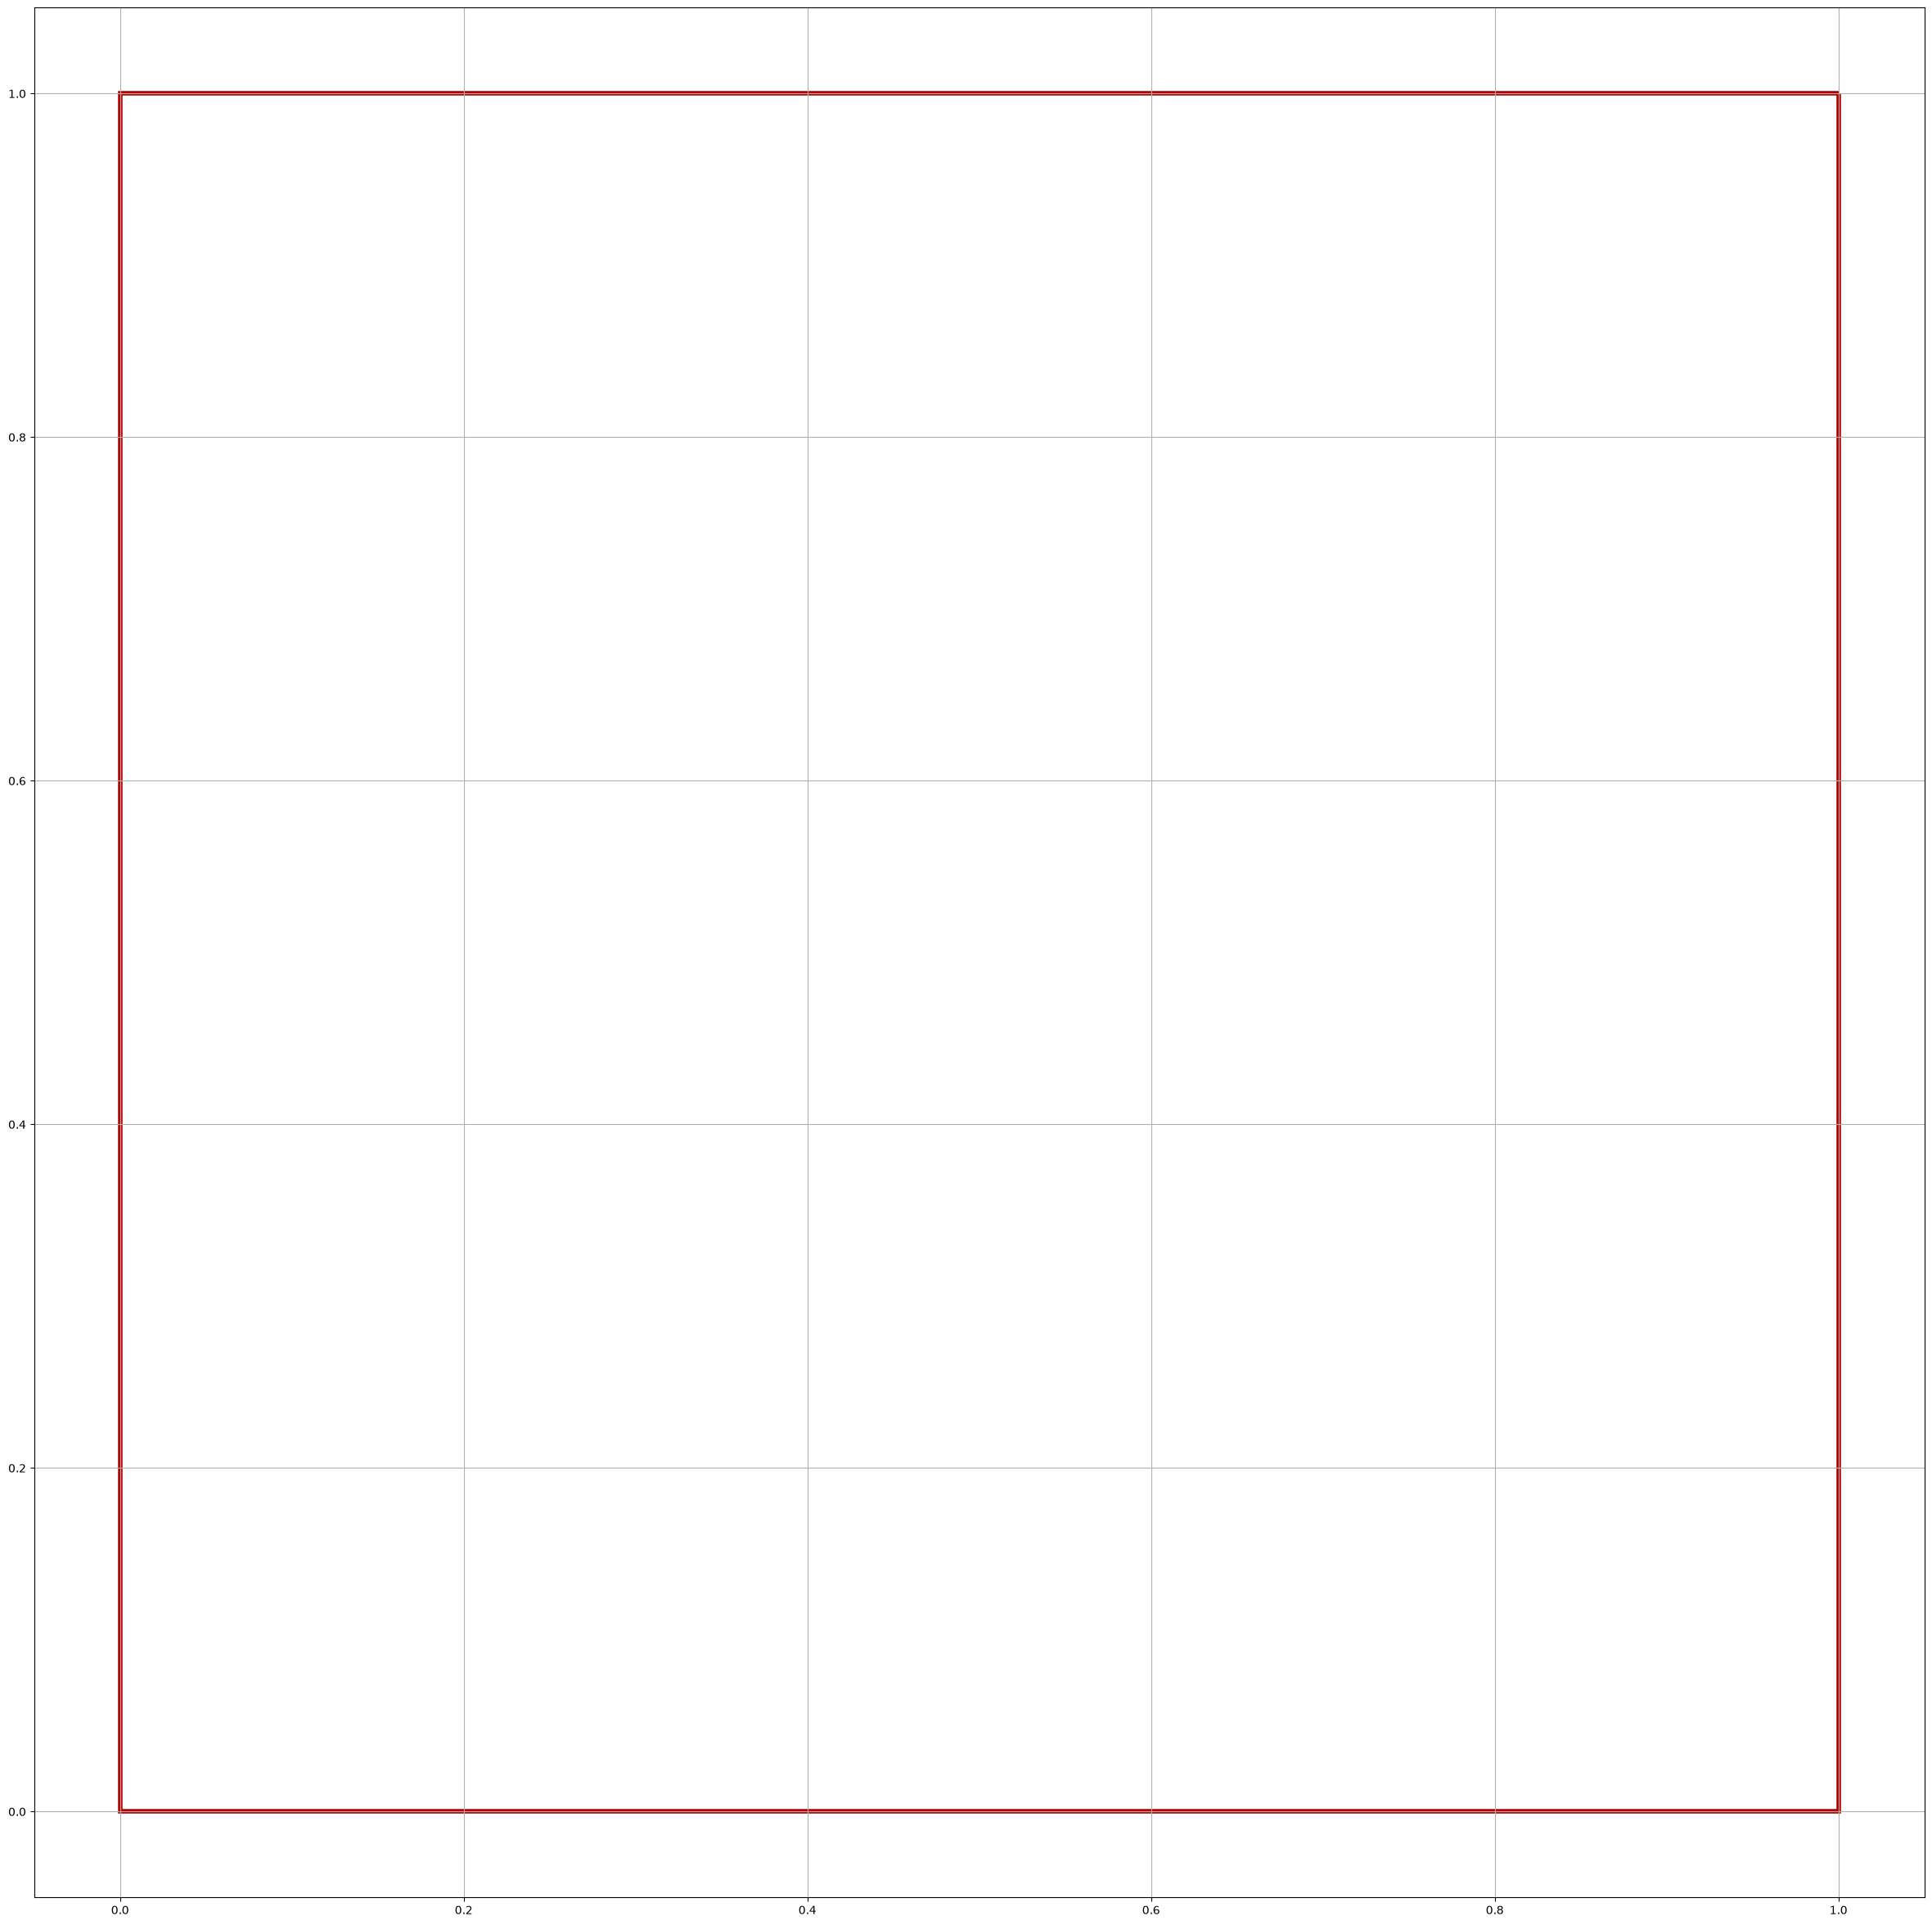

In [9]:
toolkit.logger.info("Play with EDB")
cell_names = toolkit.edb.cell_names
toolkit.edb.nets.plot()

## Save and release EDB

Save and release EDB.

In [10]:
toolkit.close_edb()

PyEDB INFO: RPC session released (open databases: 0)


C:\actions-runner\_work\pyaedt-toolkits-common\pyaedt-toolkits-common\.venv\Lib\site-packages\ansys\aedt\toolkits\common\backend\api.py:1072: FutureWarning: Call to deprecated function close_edb. Use close() instead.
  self.edb.close_edb()
INFO - EDB is closed.


True

## Remove temporary folder

Remove the temporary folder.

In [11]:
shutil.rmtree(temp_folder, ignore_errors=True)